# Нейронная сеть прямого распространения (Feedforward NN) — Кибербезопасность IoT/IIoT

**Нейронная сеть прямого распространения (Feedforward Neural Network, FNN)** — базовая архитектура 
нейронных сетей, в которой информация движется строго в одном направлении: от входного слоя через 
скрытые слои к выходному. Каждый нейрон вычисляет взвешенную сумму входов, применяет нелинейную 
функцию активации (ReLU) и передаёт результат дальше. Обучение происходит методом обратного 
распространения ошибки с использованием градиентного спуска. FNN способны аппроксимировать 
произвольные нелинейные зависимости, что делает их универсальным инструментом для классификации.

## Импорт библиотек

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import glob
import os

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score,
    ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch: {torch.__version__}")
print(f"Устройство: {device}")
print("Все библиотеки импортированы!")

PyTorch: 2.10.0+cu128
Устройство: cuda
Все библиотеки импортированы!


## Описание датасета

https://www.kaggle.com/datasets/mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot

### Краткое описание

**Edge-IIoTset** — датасет для задач кибербезопасности в среде IoT/IIoT (Интернет вещей / 
Промышленный интернет вещей). Данные собраны с реальных IoT-устройств (датчики температуры, 
влажности, камеры, шлюзы) и содержат как нормальный трафик, так и 14 типов кибератак.

### Типы атак в датасете:

| Категория | Атаки | Описание |
|-----------|-------|----------|
| **Normal** | Normal | Нормальный трафик IoT-устройств |
| **DoS/DDoS** | DDoS_UDP, DDoS_ICMP, DDoS_TCP, DDoS_HTTP | Отказ в обслуживании |
| **Reconnaissance** | Fingerprinting, Port_Scanning | Разведка и сканирование |
| **Man-in-the-Middle** | MITM | Перехват трафика |
| **Injection** | SQL_injection, XSS | Инъекции кода |
| **Malware** | Ransomware, Backdoor | Вредоносное ПО |
| **Password** | Password | Подбор паролей |
| **Vulnerability** | Vulnerability_scanner | Сканирование уязвимостей |

### Признаки:

Датасет содержит сетевые признаки (IP, порты, протоколы, флаги, длины пакетов, 
временные характеристики потоков и т.д.) — всего около 60 признаков.

In [26]:
df = pd.read_csv('/kaggle/input/datasets/mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot/Edge-IIoTset dataset/Selected dataset for ML and DL/DNN-EdgeIIoT-dataset.csv', low_memory=False)

print("=" * 60)
print("ОБЩАЯ ИНФОРМАЦИЯ")
print("=" * 60)
print(f"\nРазмер: {df.shape[0]:,} строк, {df.shape[1]} столбцов")
print(f"Столбцы: {list(df.columns)}")

print("\n" + "=" * 60)
print("ПЕРВЫЕ 5 СТРОК")
print("=" * 60)
df.head()

ОБЩАЯ ИНФОРМАЦИЯ

Размер: 2,219,201 строк, 63 столбцов
Столбцы: ['frame.time', 'ip.src_host', 'ip.dst_host', 'arp.dst.proto_ipv4', 'arp.opcode', 'arp.hw.size', 'arp.src.proto_ipv4', 'icmp.checksum', 'icmp.seq_le', 'icmp.transmit_timestamp', 'icmp.unused', 'http.file_data', 'http.content_length', 'http.request.uri.query', 'http.request.method', 'http.referer', 'http.request.full_uri', 'http.request.version', 'http.response', 'http.tls_port', 'tcp.ack', 'tcp.ack_raw', 'tcp.checksum', 'tcp.connection.fin', 'tcp.connection.rst', 'tcp.connection.syn', 'tcp.connection.synack', 'tcp.dstport', 'tcp.flags', 'tcp.flags.ack', 'tcp.len', 'tcp.options', 'tcp.payload', 'tcp.seq', 'tcp.srcport', 'udp.port', 'udp.stream', 'udp.time_delta', 'dns.qry.name', 'dns.qry.name.len', 'dns.qry.qu', 'dns.qry.type', 'dns.retransmission', 'dns.retransmit_request', 'dns.retransmit_request_in', 'mqtt.conack.flags', 'mqtt.conflag.cleansess', 'mqtt.conflags', 'mqtt.hdrflags', 'mqtt.len', 'mqtt.msg_decoded_as', 'mqtt.m

,frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,...,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
0,2021 11:44:10.081753000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
1,2021 11:44:10.162218000,192.168.0.101,192.168.0.128,0,0.0,0.0,0,0.0,0.0,0.0,...,4.0,MQTT,0,0.0,4.0,0.0,0.0,0.0,0,Normal
2,2021 11:44:10.162271000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
3,2021 11:44:10.162641000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
4,2021 11:44:10.166132000,192.168.0.101,192.168.0.128,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,Temperature_and_Humidity,24.0,0.0,0.0,0.0,0.0,0,Normal


In [27]:
print("=" * 60)
print("ТИПЫ ДАННЫХ")
print("=" * 60)
print(df.dtypes.value_counts())

print("\n" + "=" * 60)
print("ПРОПУСКИ (топ-10)")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'Пропуски': missing, '%': missing_pct})[missing > 0].sort_values('%', ascending=False).head(10))

ТИПЫ ДАННЫХ
float64    42
object     20
int64       1
Name: count, dtype: int64

ПРОПУСКИ (топ-10)
Empty DataFrame
Columns: [Пропуски, %]
Index: []


Столбец с метками: 'Attack_type'

Распределение классов:
Attack_type
Normal                   1615643
DDoS_UDP                  121568
DDoS_ICMP                 116436
SQL_injection              51203
Password                   50153
Vulnerability_scanner      50110
DDoS_TCP                   50062
DDoS_HTTP                  49911
Uploading                  37634
Backdoor                   24862
Port_Scanning              22564
XSS                        15915
Ransomware                 10925
MITM                        1214
Fingerprinting              1001
Name: count, dtype: int64


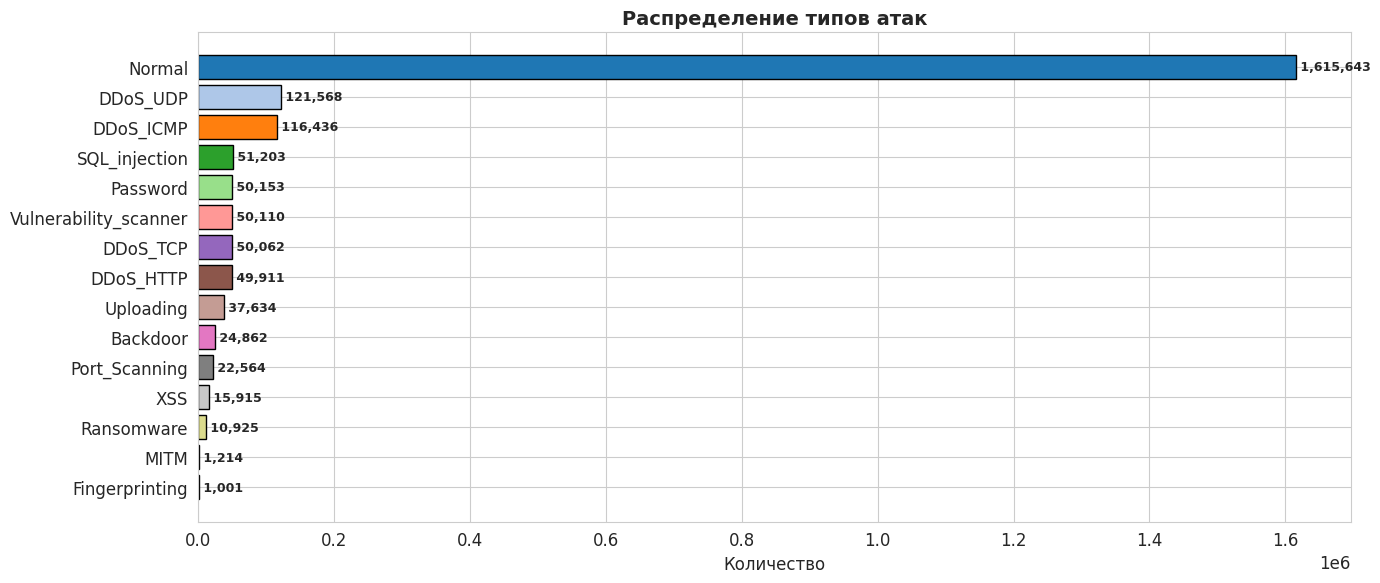

In [28]:
# Определяем столбец с метками
label_candidates = ['Attack_type', 'attack_type', 'Attack_label', 'attack_label', 'label', 'Label']
label_col = None
for c in label_candidates:
    if c in df.columns:
        label_col = c
        break

# Если не нашли — ищем столбец с малым числом уникальных значений
if label_col is None:
    for c in df.columns:
        if df[c].dtype == 'object' and 2 < df[c].nunique() < 30:
            label_col = c
            break

print(f"Столбец с метками: '{label_col}'")
print(f"\nРаспределение классов:")
print(df[label_col].value_counts())

fig, ax = plt.subplots(figsize=(14, 6))
counts = df[label_col].value_counts()
colors = plt.cm.tab20(np.linspace(0, 1, len(counts)))
bars = ax.barh(counts.index, counts.values, color=colors, edgecolor='black')
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
            f' {v:,}', va='center', fontweight='bold', fontsize=9)
ax.set_title('Распределение типов атак', fontsize=14, fontweight='bold')
ax.set_xlabel('Количество')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Предварительная обработка датасета

In [29]:
 # Сэмплирование (датасет может быть огромным)
MAX_SAMPLES = 300000

if len(df) > MAX_SAMPLES:
    print(f"Датасет слишком большой ({len(df):,}). Стратифицированная выборка {MAX_SAMPLES:,}...")
    
    # Минимум 50 образцов от каждого класса
    samples = []
    for cls in df[label_col].unique():
        cls_data = df[df[label_col] == cls]
        n = max(50, int(MAX_SAMPLES * len(cls_data) / len(df)))
        n = min(n, len(cls_data))
        samples.append(cls_data.sample(n=n, random_state=42))
    
    df = pd.concat(samples, ignore_index=True)
    print(f"После сэмплирования: {len(df):,}")

print(f"\nРаспределение после сэмплирования:")
print(df[label_col].value_counts())

Датасет слишком большой (2,219,201). Стратифицированная выборка 300,000...
После сэмплирования: 299,993

Распределение после сэмплирования:
Attack_type
Normal                   218408
DDoS_UDP                  16434
DDoS_ICMP                 15740
SQL_injection              6921
Password                   6779
Vulnerability_scanner      6774
DDoS_TCP                   6767
DDoS_HTTP                  6747
Uploading                  5087
Backdoor                   3360
Port_Scanning              3050
XSS                        2151
Ransomware                 1476
MITM                        164
Fingerprinting              135
Name: count, dtype: int64


In [30]:
# Удаление ненужных столбцов
drop_cols = []
for c in df.columns:
    if c == label_col:
        continue
    # IP-адреса, временные метки, идентификаторы
    if any(kw in c.lower() for kw in ['ip', 'timestamp', 'time', 'date', 'unnamed']):
        drop_cols.append(c)
    # Столбцы с одним уникальным значением
    elif df[c].nunique() <= 1:
        drop_cols.append(c)

print(f"Удаляемые столбцы ({len(drop_cols)}): {drop_cols}")
df = df.drop(columns=drop_cols, errors='ignore')
print(f"Размер после удаления: {df.shape}")

Удаляемые столбцы (11): ['frame.time', 'ip.src_host', 'ip.dst_host', 'arp.dst.proto_ipv4', 'arp.src.proto_ipv4', 'icmp.transmit_timestamp', 'icmp.unused', 'http.tls_port', 'udp.time_delta', 'dns.qry.type', 'mqtt.msg_decoded_as']
Размер после удаления: (299993, 52)


In [32]:
# Обработка типов данных
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c != label_col]
print(f"Категориальные столбцы ({len(cat_cols)}): {cat_cols}")

for c in cat_cols:
    n_unique = df[c].nunique()
    enc = LabelEncoder()
    df[c] = enc.fit_transform(df[c].astype(str))
    print(f"  {c}: {n_unique} категорий → закодирован числами 0..{n_unique-1}")

# Приведение к числовому типу
for c in df.columns:
    if c != label_col:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# Удаление пропусков
before = len(df)
df = df.dropna()
print(f"\nУдалено строк с пропусками: {before - len(df)}")
print(f"Итоговый размер: {df.shape}")

Категориальные столбцы (14): ['http.file_data', 'http.request.uri.query', 'http.request.method', 'http.referer', 'http.request.full_uri', 'http.request.version', 'tcp.options', 'tcp.payload', 'tcp.srcport', 'dns.qry.name.len', 'mqtt.conack.flags', 'mqtt.msg', 'mqtt.protoname', 'mqtt.topic']
  http.file_data: 353 категорий → закодирован числами 0..352
  http.request.uri.query: 1264 категорий → закодирован числами 0..1263
  http.request.method: 6 категорий → закодирован числами 0..5
  http.referer: 5 категорий → закодирован числами 0..4
  http.request.full_uri: 2956 категорий → закодирован числами 0..2955
  http.request.version: 7 категорий → закодирован числами 0..6
  tcp.options: 36650 категорий → закодирован числами 0..36649
  tcp.payload: 38247 категорий → закодирован числами 0..38246
  tcp.srcport: 33800 категорий → закодирован числами 0..33799
  dns.qry.name.len: 9 категорий → закодирован числами 0..8
  mqtt.conack.flags: 6 категорий → закодирован числами 0..5
  mqtt.msg: 131 катег

In [33]:
# Разделяем X и y
le = LabelEncoder()
y_all = le.fit_transform(df[label_col])
class_names = le.classes_
X_all = df.drop(columns=[label_col]).values.astype(np.float32)

# Замена inf
X_all = np.nan_to_num(X_all, nan=0.0, posinf=0.0, neginf=0.0)

print(f"Классы ({len(class_names)}): {list(class_names)}")
print(f"X: {X_all.shape}")

# Стратифицированное разделение
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)
print(f"\nX_train: {X_train.shape}, X_test: {X_test.shape}")

Классы (15): ['Backdoor', 'DDoS_HTTP', 'DDoS_ICMP', 'DDoS_TCP', 'DDoS_UDP', 'Fingerprinting', 'MITM', 'Normal', 'Password', 'Port_Scanning', 'Ransomware', 'SQL_injection', 'Uploading', 'Vulnerability_scanner', 'XSS']
X: (299993, 51)

X_train: (239994, 51), X_test: (59999, 51)


In [34]:
# Балансировка обучающей выборки
counts = np.bincount(y_train)
target_size = int(np.median(counts))

print(f"Целевой размер после балансировки: {target_size}")

X_balanced, y_balanced = [], []
for cls in range(len(class_names)):
    mask = y_train == cls
    X_cls = X_train[mask]
    y_cls = y_train[mask]

    if len(X_cls) < target_size:
        X_res, y_res = resample(X_cls, y_cls, replace=True,
                                 n_samples=target_size, random_state=42)
    elif len(X_cls) > target_size * 3:
        X_res, y_res = resample(X_cls, y_cls, replace=False,
                                 n_samples=target_size * 2, random_state=42)
    else:
        X_res, y_res = X_cls, y_cls

    X_balanced.append(X_res)
    y_balanced.append(y_res)

X_train = np.vstack(X_balanced)
y_train = np.concatenate(y_balanced)

shuffle = np.random.RandomState(42).permutation(len(y_train))
X_train = X_train[shuffle]
y_train = y_train[shuffle]

print(f"\nПосле балансировки: {X_train.shape}")
for i, name in enumerate(class_names):
    print(f"  {name}: {(y_train == i).sum()}")

# Масштабирование
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Замена inf после масштабирования
X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)

print("\nМасштабирование выполнено!")

Целевой размер после балансировки: 5398

После балансировки: (101511, 51)
  Backdoor: 5398
  DDoS_HTTP: 5398
  DDoS_ICMP: 12592
  DDoS_TCP: 5413
  DDoS_UDP: 13147
  Fingerprinting: 5398
  MITM: 5398
  Normal: 10796
  Password: 5423
  Port_Scanning: 5398
  Ransomware: 5398
  SQL_injection: 5537
  Uploading: 5398
  Vulnerability_scanner: 5419
  XSS: 5398

Масштабирование выполнено!


## Тепловая карта корреляций (Heatmap)

Для наглядности строим корреляцию по 20 наиболее важным числовым признакам.

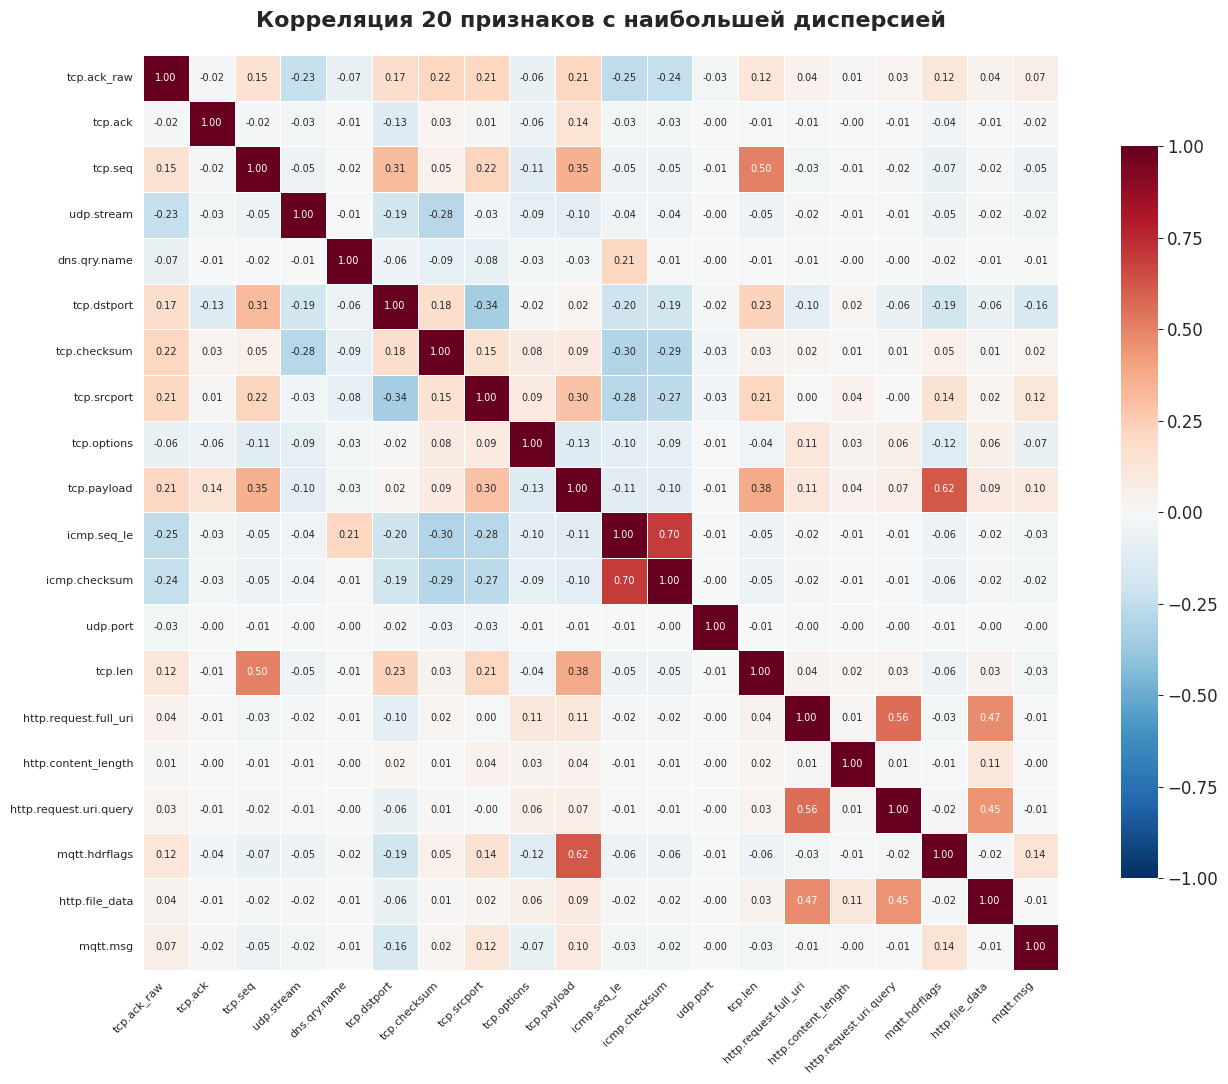

In [35]:
# Топ-20 признаков по дисперсии
feature_names = df.drop(columns=[label_col]).columns.tolist()
variances = pd.Series(X_all.var(axis=0), index=feature_names)
top_feats = variances.sort_values(ascending=False).head(20).index.tolist()

fig, ax = plt.subplots(figsize=(14, 11))
corr = pd.DataFrame(X_all, columns=feature_names)[top_feats].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8}, vmin=-1, vmax=1, annot_kws={'size': 7})
ax.set_title('Корреляция 20 признаков с наибольшей дисперсией',
             fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

## Построение и обучение нейронной сети

In [36]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

BATCH_SIZE = 512
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

n_features = X_train.shape[1]
n_classes = len(class_names)
print(f"Признаков: {n_features}, Классов: {n_classes}")
print(f"Train: {len(y_train):,}, Test: {len(y_test):,}")

Признаков: 51, Классов: 15
Train: 101,511, Test: 59,999


In [37]:
class FeedForwardNN(nn.Module):
    def __init__(self, input_dim, n_classes):
        super(FeedForwardNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        return self.network(x)

model = FeedForwardNN(n_features, n_classes).to(device)

print("=" * 60)
print("АРХИТЕКТУРА")
print("=" * 60)
print(model)
print(f"\nПараметров: {sum(p.numel() for p in model.parameters()):,}")

АРХИТЕКТУРА
FeedForwardNN(
  (network): Sequential(
    (0): Linear(in_features=51, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=64, out_features=15, bias=True)
  )
)

Параметров: 56,335


In [38]:
# Веса классов
class_counts_train = np.bincount(y_train, minlength=n_classes)
class_weights = np.sqrt(class_counts_train.max() / (class_counts_train + 1))
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("=" * 60)
print("ВЕСА КЛАССОВ")
print("=" * 60)
for i, name in enumerate(class_names):
    print(f"  {name:<25}: {class_counts_train[i]:>6}, вес = {class_weights[i]:.4f}")

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-6)

EPOCHS = 100
PATIENCE = 20

train_losses, test_losses = [], []
train_accs, test_accs = [], []
best_test_f1 = 0.0
best_epoch = 0
best_model_state = None
epochs_no_improve = 0

print("\n" + "=" * 60)
print("ОБУЧЕНИЕ")
print("=" * 60)

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

    train_losses.append(running_loss / total)
    train_accs.append(correct / total)

    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds_epoch = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_loss += loss.item() * X_batch.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
            all_preds_epoch.extend(predicted.cpu().numpy())

    test_losses.append(running_loss / total)
    test_accs.append(correct / total)

    epoch_f1 = f1_score(y_test, np.array(all_preds_epoch), average='macro')
    scheduler.step()

    if epoch_f1 > best_test_f1:
        best_test_f1 = epoch_f1
        best_epoch = epoch + 1
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"  Эпоха {epoch+1:3d}/{EPOCHS} | "
              f"Train: {train_accs[-1]:.4f} | Test: {test_accs[-1]:.4f} | "
              f"F1m: {epoch_f1:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

    if epochs_no_improve >= PATIENCE:
        print(f"\n  Early stopping (эпоха {epoch+1})")
        break

model.load_state_dict(best_model_state)
print(f"\nЛучший F1 macro: {best_test_f1:.4f} (эпоха {best_epoch})")

ВЕСА КЛАССОВ
  Backdoor                 :   5398, вес = 1.5605
  DDoS_HTTP                :   5398, вес = 1.5605
  DDoS_ICMP                :  12592, вес = 1.0218
  DDoS_TCP                 :   5413, вес = 1.5583
  DDoS_UDP                 :  13147, вес = 1.0000
  Fingerprinting           :   5398, вес = 1.5605
  MITM                     :   5398, вес = 1.5605
  Normal                   :  10796, вес = 1.1035
  Password                 :   5423, вес = 1.5569
  Port_Scanning            :   5398, вес = 1.5605
  Ransomware               :   5398, вес = 1.5605
  SQL_injection            :   5537, вес = 1.5408
  Uploading                :   5398, вес = 1.5605
  Vulnerability_scanner    :   5419, вес = 1.5574
  XSS                      :   5398, вес = 1.5605

ОБУЧЕНИЕ
  Эпоха   1/100 | Train: 0.7681 | Test: 0.9678 | F1m: 0.8312 | LR: 0.001000
  Эпоха  10/100 | Train: 0.9543 | Test: 0.9923 | F1m: 0.9164 | LR: 0.000976
  Эпоха  20/100 | Train: 0.9581 | Test: 0.9923 | F1m: 0.9176 | LR: 0.000905

## Прогнозы модели

In [39]:
model.eval()
all_preds, all_probs = [], []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

y_pred = np.array(all_preds)
y_pred_proba = np.array(all_probs)

print("=" * 60)
print("ПРОГНОЗЫ")
print("=" * 60)

comparison = pd.DataFrame({
    'Истинный': le.inverse_transform(y_test[:25]),
    'Предсказание': le.inverse_transform(y_pred[:25]),
    'OK': ['✓' if a == b else '✗' for a, b in zip(y_test[:25], y_pred[:25])]
})
print(comparison.to_string(index=False))

correct = (y_pred == y_test).sum()
print(f"\nПравильно: {correct} из {len(y_test)} ({correct/len(y_test)*100:.2f}%)")

ПРОГНОЗЫ
 Истинный Предсказание OK
   Normal       Normal  ✓
   Normal       Normal  ✓
   Normal       Normal  ✓
   Normal       Normal  ✓
   Normal       Normal  ✓
   Normal       Normal  ✓
 Password     Password  ✓
   Normal       Normal  ✓
   Normal       Normal  ✓
   Normal       Normal  ✓
DDoS_ICMP    DDoS_ICMP  ✓
 Password     Password  ✓
   Normal       Normal  ✓
   Normal       Normal  ✓
   Normal       Normal  ✓
   Normal       Normal  ✓
 Backdoor     Backdoor  ✓
   Normal       Normal  ✓
 DDoS_UDP     DDoS_UDP  ✓
   Normal       Normal  ✓
 DDoS_UDP     DDoS_UDP  ✓
   Normal       Normal  ✓
   Normal       Normal  ✓
DDoS_ICMP    DDoS_ICMP  ✓
Uploading    Uploading  ✓

Правильно: 59710 из 59999 (99.52%)


## Графики выходных результатов и метрики

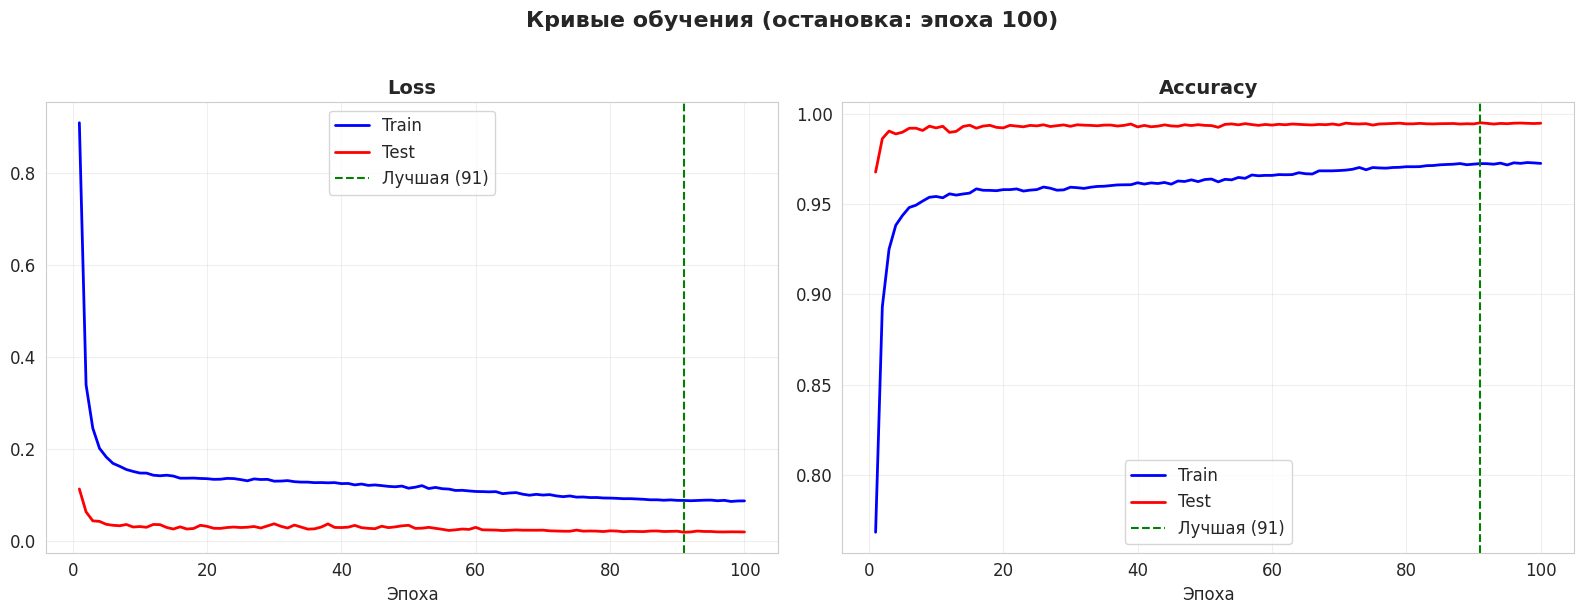

In [40]:
# Кривые обучения
actual_epochs = len(train_losses)
epochs_range = range(1, actual_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(epochs_range, train_losses, 'b-', lw=2, label='Train')
axes[0].plot(epochs_range, test_losses, 'r-', lw=2, label='Test')
axes[0].axvline(x=best_epoch, color='green', linestyle='--', lw=1.5,
                label=f'Лучшая ({best_epoch})')
axes[0].set_title('Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Эпоха')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, train_accs, 'b-', lw=2, label='Train')
axes[1].plot(epochs_range, test_accs, 'r-', lw=2, label='Test')
axes[1].axvline(x=best_epoch, color='green', linestyle='--', lw=1.5,
                label=f'Лучшая ({best_epoch})')
axes[1].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Эпоха')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Кривые обучения (остановка: эпоха {actual_epochs})',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [41]:
# Метрики
accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')
precision_macro = precision_score(y_test, y_pred, average='macro')
recall_macro = recall_score(y_test, y_pred, average='macro')

print("=" * 60)
print("МЕТРИКИ")
print("=" * 60)
print(f"\n  Accuracy:           {accuracy:.4f}")
print(f"  Precision (macro):  {precision_macro:.4f}")
print(f"  Recall (macro):     {recall_macro:.4f}")
print(f"  F1 (macro):         {f1_macro:.4f}")
print(f"  F1 (weighted):      {f1_weighted:.4f}")

print("\n" + "=" * 60)
print("ПОДРОБНЫЙ ОТЧЁТ")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=class_names))

МЕТРИКИ

  Accuracy:           0.9952
  Precision (macro):  0.9219
  Recall (macro):     0.9588
  F1 (macro):         0.9307
  F1 (weighted):      0.9957

ПОДРОБНЫЙ ОТЧЁТ
                       precision    recall  f1-score   support

             Backdoor       1.00      0.96      0.98       672
            DDoS_HTTP       0.99      0.99      0.99      1349
            DDoS_ICMP       1.00      0.99      0.99      3148
             DDoS_TCP       1.00      0.92      0.96      1354
             DDoS_UDP       1.00      1.00      1.00      3287
       Fingerprinting       0.18      0.67      0.29        27
                 MITM       1.00      1.00      1.00        33
               Normal       1.00      1.00      1.00     43682
             Password       1.00      0.98      0.99      1356
        Port_Scanning       0.84      0.93      0.89       610
           Ransomware       0.86      0.95      0.90       295
        SQL_injection       0.99      1.00      0.99      1384
         

In [42]:
# Точность по каждому классу + с чем путает
cm = confusion_matrix(y_test, y_pred)

print("=" * 70)
print("ТОЧНОСТЬ ПО КАЖДОМУ КЛАССУ И ОСНОВНЫЕ ОШИБКИ")
print("=" * 70)
print(f"\n  {'Класс':<25} {'Верно':>8} {'Всего':>8} {'Точность':>10}")
print(f"  {'-'*53}")

for i, name in enumerate(class_names):
    total_cls = cm[i].sum()
    correct_cls = cm[i, i]
    acc_cls = correct_cls / total_cls if total_cls > 0 else 0
    print(f"  {name:<25} {correct_cls:>8} {total_cls:>8} {acc_cls:>10.4f}")

    # Топ ошибок: с какими классами путает
    errors = cm[i].copy()
    errors[i] = 0  # убираем правильные
    if errors.sum() > 0:
        top_errors_idx = np.argsort(errors)[::-1]
        for j in top_errors_idx:
            if errors[j] == 0:
                break
            err_pct = errors[j] / total_cls * 100
            print(f"    └─ путает с {class_names[j]:<20}: {errors[j]:>5} ({err_pct:.1f}%)")

print(f"  {'-'*53}")
print(f"  {'ОБЩАЯ':<25} {cm.diagonal().sum():>8} {cm.sum():>8} {accuracy:>10.4f}")

ТОЧНОСТЬ ПО КАЖДОМУ КЛАССУ И ОСНОВНЫЕ ОШИБКИ

  Класс                        Верно    Всего   Точность
  -----------------------------------------------------
  Backdoor                       648      672     0.9643
    └─ путает с Ransomware          :    14 (2.1%)
    └─ путает с Fingerprinting      :     6 (0.9%)
    └─ путает с Port_Scanning       :     4 (0.6%)
  DDoS_HTTP                     1342     1349     0.9948
    └─ путает с XSS                 :     5 (0.4%)
    └─ путает с Vulnerability_scanner:     2 (0.1%)
  DDoS_ICMP                     3111     3148     0.9882
    └─ путает с Fingerprinting      :    35 (1.1%)
    └─ путает с Port_Scanning       :     2 (0.1%)
  DDoS_TCP                      1246     1354     0.9202
    └─ путает с Port_Scanning       :    91 (6.7%)
    └─ путает с Fingerprinting      :    17 (1.3%)
  DDoS_UDP                      3283     3287     0.9988
    └─ путает с Ransomware          :     4 (0.1%)
  Fingerprinting                  18       27

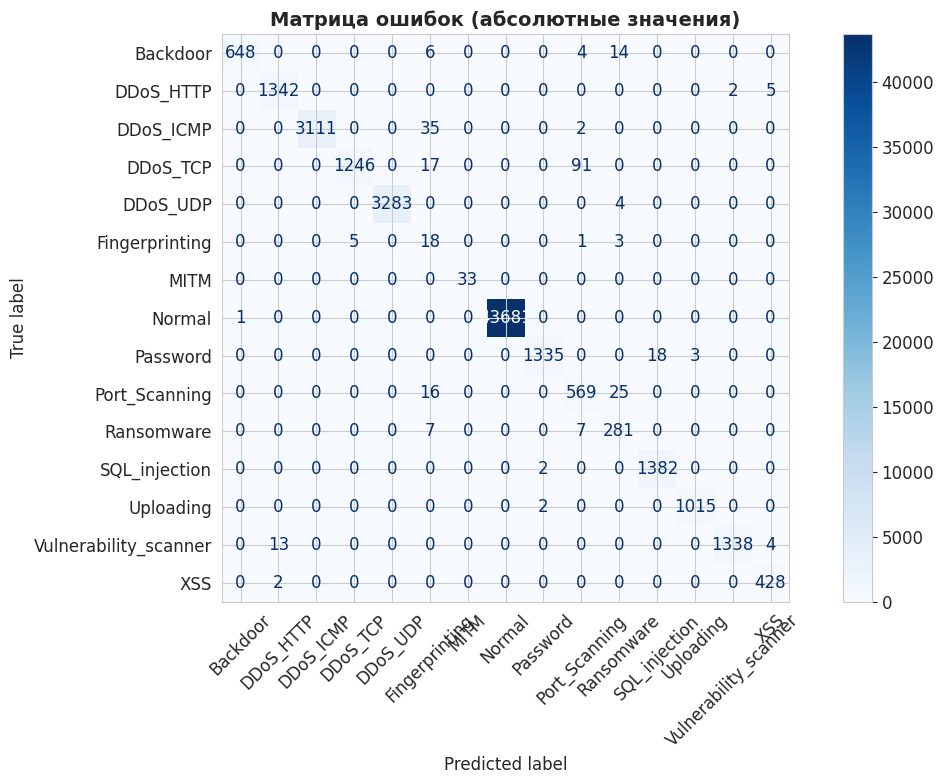

In [43]:
# Матрица ошибок (абсолютные значения)
fig, ax = plt.subplots(figsize=(12, 8))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    cmap='Blues', ax=ax, values_format='d')
ax.set_title('Матрица ошибок (абсолютные значения)', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

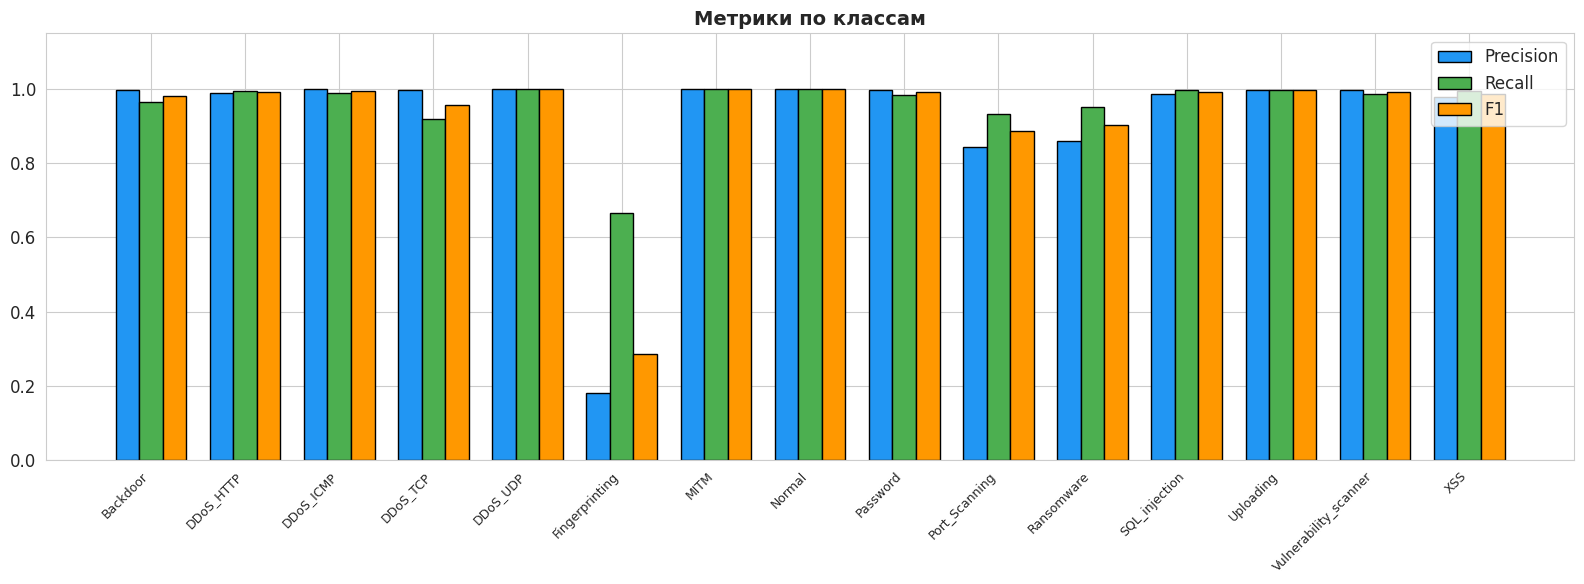

In [44]:
# Метрики по классам
report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)

pr_vals = [report[c]['precision'] for c in class_names]
rc_vals = [report[c]['recall'] for c in class_names]
f1_vals = [report[c]['f1-score'] for c in class_names]

x = np.arange(len(class_names))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x - width, pr_vals, width, label='Precision', color='#2196F3', edgecolor='black')
ax.bar(x, rc_vals, width, label='Recall', color='#4CAF50', edgecolor='black')
ax.bar(x + width, f1_vals, width, label='F1', color='#FF9800', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
ax.set_title('Метрики по классам', fontsize=14, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.show()

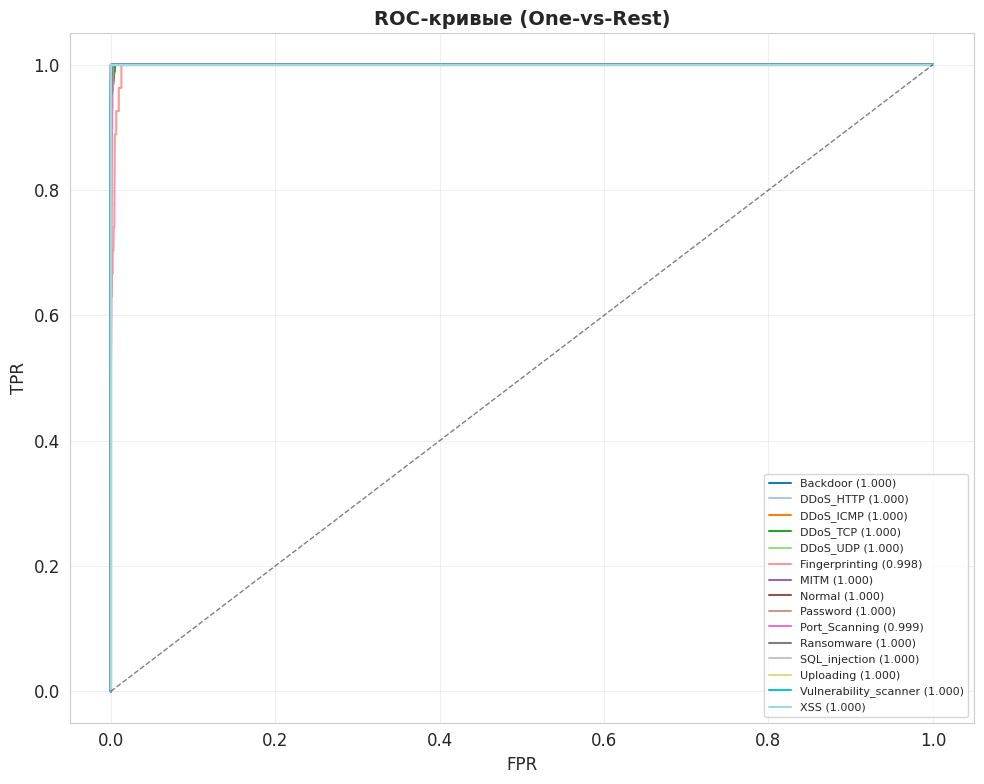

In [45]:
# ROC-кривые
y_test_bin = label_binarize(y_test, classes=range(n_classes))

fig, ax = plt.subplots(figsize=(10, 8))
colors_roc = plt.cm.tab20(np.linspace(0, 1, n_classes))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors_roc[i], lw=1.5,
            label=f'{class_names[i]} ({roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_title('ROC-кривые (One-vs-Rest)', fontsize=14, fontweight='bold')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()